In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# E类型，19
# input: 3*128*128
class VGGNet(nn.Module):
    def __init__(self, num_classes=101):
        super(VGGNet, self).__init__()

        self.features = nn.Sequential(
            # 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Linear(512 * 4 * 4, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

In [2]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from PIL import Image
import os
import matplotlib.pyplot as plt


class DataSetLoader_test(Dataset):
    def __init__(self, root_dir, transform=None, num_classes=101, return_pil=False):
        self.root_dir = root_dir
        self.transform = transform
        self.num_classes = num_classes
        # 如果 return_pil 为 True，则 __getitem__ 返回 PIL 图像而不是张量
        self.return_pil = return_pil

        # 收集所有 (img_path, label_idx)
        self.samples = []
        self.class_names = sorted(
            [
                d
                for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ]
        )[: self.num_classes]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                    img_path = os.path.join(cls_dir, fname)
                    label = self.class_to_idx[cls_name]
                    self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.return_pil:
            return image, label

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [3]:
import random

class DataSetLoader_train(Dataset):
  def __init__(self, root_dir, transform=None, num_classes=101, split_ratio=0.8, return_pil=False, dataclass="train"):
    self.root_dir = root_dir
    self.transform = transform
    self.num_classes = num_classes
    self.split_ratio = split_ratio
    self.return_pil = return_pil
    self.dataclass = dataclass
    self.trainSamples = []
    self.validSamples = []
    self.class_names = sorted(
      [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
    )[: self.num_classes]
    self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.class_names)}
    self.train_count = {cls_name: 0 for cls_name in self.class_names}
    self.valid_count = {cls_name: 0 for cls_name in self.class_names}

    for cls_name in self.class_names:
      cls_dir = os.path.join(root_dir, cls_name)
      cls_samples = []
      for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
          img_path = os.path.join(cls_dir, fname)
          label = self.class_to_idx[cls_name]
          cls_samples.append((img_path, label))
      random.shuffle(cls_samples)
      split_idx = int(len(cls_samples) * self.split_ratio)
      train_split = cls_samples[:split_idx]
      valid_split = cls_samples[split_idx:]
      self.trainSamples.extend(train_split)  # 前80% 训练样本
      self.validSamples.extend(valid_split)  # 后20% 验证样本
      self.train_count[cls_name] += len(train_split)
      self.valid_count[cls_name] += len(valid_split)

  def __len__(self):
    if self.dataclass == "train":
      return len(self.trainSamples)
    else:
      return len(self.validSamples)

  def __getitem__(self, idx):
    if self.dataclass == "train":
      img_path, label = self.trainSamples[idx]
    else:
      img_path, label = self.validSamples[idx]
    image = Image.open(img_path).convert("RGB")

    if self.return_pil:
      return image, label

    if self.transform is not None:
      image = self.transform(image)
    else:
      transform = T.Compose(
        [
          T.Resize((128, 128)),
          T.ToTensor(),
          T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
      )
      image = transform(image)

    return image, label

In [4]:
from tqdm import tqdm


def test_val(model, val_loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="验证中"):
            images, labels = images.to(device), labels.to(device)
            if images.dim() == 5:
                bsz, ncrops, c, h, w = images.size()
                outputs = model(images.view(-1, c, h, w))
                outputs = outputs.view(bsz, ncrops, -1).mean(dim=1)
            else:
                outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / max(total, 1)
    accuracy = correct / max(total, 1)
    return accuracy

In [5]:
def train(
    model,
    epoch,
    train_loader,
    optimizer,
    criterion,
    device,
    scheduler=None,
    val_loader=None,
):
    train_acc = []
    val_acc = []
    loss_history = []

    for ep in range(epoch):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"训练中 [{ep+1}/{epoch}]"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            batch_loss = criterion(outputs, labels)
            batch_loss.backward()
            optimizer.step()

            total_loss += batch_loss.item() * labels.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / max(total, 1)
        accuracy = correct / max(total, 1)
        train_acc.append(accuracy)
        loss_history.append(avg_loss)

        val_acc_ = None
        if val_loader is not None:
            val_acc_ = test_val(model, val_loader, criterion, device)
            val_acc.append(val_acc_)

        if scheduler is not None:
            if val_acc_ is None:
                scheduler.step()
            else:
                scheduler.step(val_acc_)

        if val_acc_ is None:
            print(
                f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 训练准确率: {accuracy:.4f}"
            )
        else:
            print(
                f"Epoch [{ep+1}/{epoch}] 平均损失: {avg_loss:.4f} 训练准确率: {accuracy:.4f} 验证准确率: {val_acc_:.4f}"
            )

    return train_acc, loss_history, val_acc

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_acc_loss(train_acc, loss, val_acc=None):
    epochs = np.arange(1, len(train_acc) + 1)
    plt.figure(figsize=(16, 5))

    # --- 准确率曲线 ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, "o-", label="Train Acc", color="C0")
    if val_acc is not None and len(val_acc) == len(train_acc):
        plt.plot(epochs, val_acc, "o-", label="Val Acc", color="C1")
        best_val_idx = np.argmax(val_acc)
        plt.scatter(epochs[best_val_idx], val_acc[best_val_idx], color="red", label="Best Val Acc")
        plt.text(epochs[best_val_idx], val_acc[best_val_idx], f"{val_acc[best_val_idx]:.4f}", color="red", fontsize=12, va="bottom")
    best_train_idx = np.argmax(train_acc)
    plt.scatter(epochs[best_train_idx], train_acc[best_train_idx], color="blue", label="Best Train Acc")
    plt.text(epochs[best_train_idx], train_acc[best_train_idx], f"{train_acc[best_train_idx]:.4f}", color="blue", fontsize=12, va="bottom")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()
    plt.grid(True)

    # --- 损失曲线 ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, "o-", label="Train Loss", color="orange")
    best_loss_idx = np.argmin(loss)
    plt.scatter(epochs[best_loss_idx], loss[best_loss_idx], color="green", label="Best Train Loss")
    plt.text(epochs[best_loss_idx], loss[best_loss_idx], f"{loss[best_loss_idx]:.5f}", color="green", fontsize=12, va="bottom")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
import random
from torchvision.transforms.v2 import ScaleJitter

train_dir = "/data/data_taohy/awesomeCopression/food101_images/train"
test_dir = "/data/data_taohy/awesomeCopression/food101_images/validation"

NUM_CLASSES = 101
BATCH_SIZE = 64
mean = [0.5449, 0.4433, 0.3435]
std = [0.2271, 0.2376, 0.2350]

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
model = VGGNet(num_classes=NUM_CLASSES)
model.init_weights()
if torch.cuda.device_count() > 1:
    print("使用多卡训练, GPU 数量:", torch.cuda.device_count())
    model = nn.DataParallel(model)
model = model.to(device)


# S = [150,300]
transform_train = T.Compose(
    [
        ScaleJitter((128, 128), (150 / 128, 300 / 128)),
        T.Resize((128, 128)), 
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ]
)

# S = 150
transform_val = T.Compose(
    [
        T.Resize((150, 150)),
        T.CenterCrop((128, 128)),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ]
)

train_dataset = DataSetLoader_train(
    root_dir=train_dir,
    num_classes=NUM_CLASSES,
    transform=transform_train,
    split_ratio=0.8,
    return_pil=False,
    dataclass="train",
)
val_dataset = DataSetLoader_train(
    root_dir=train_dir,
    num_classes=NUM_CLASSES,
    transform=transform_val,
    split_ratio=0.8,
    return_pil=False,
    dataclass="valid",
)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4
)

scheduler_base = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",  # 监控准确率（越大越好）
    factor=0.1,  # 乘以 0.1（即除以 10）
    patience=5,  # 等待 5 个 epoch 不改善才调整
)

criterion = nn.CrossEntropyLoss()

train_acc, loss, val_acc = train(
    model,
    epoch=30,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
    val_loader=val_loader,
 )

使用多卡训练, GPU 数量: 4


验证中: 100%|██████████| 237/237 [00:19<00:00, 11.99it/s]


Epoch [1/30] 平均损失: 4.6123 训练准确率: 0.0102 验证准确率: 0.0112


验证中: 100%|██████████| 237/237 [00:19<00:00, 11.94it/s]


Epoch [2/30] 平均损失: 4.6128 训练准确率: 0.0091 验证准确率: 0.0099


...

Epoch [28/30] 平均损失: 1.8044 训练准确率: 0.5226 验证准确率: 0.5112


验证中: 100%|██████████| 237/237 [00:19<00:00, 11.86it/s]


Epoch [29/30] 平均损失: 1.7232 训练准确率: 0.5440 验证准确率: 0.4714


验证中: 100%|██████████| 237/237 [00:19<00:00, 11.97it/s]

Epoch [30/30] 平均损失: 1.6328 训练准确率: 0.5644 验证准确率: 0.5098


In [8]:
import os
from datetime import datetime

# 保存/加载检查点的实用函数（在新的 notebook cell 中执行）
def save_checkpoint(path, model, optimizer, scheduler=None, epoch=None, best_acc=None):
  os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
  # 如果使用了 DataParallel，保存 module 的 state_dict
  state_dict = model.module.state_dict() if hasattr(model, "module") else model.state_dict()
  checkpoint = {
    "epoch": epoch,
    "model_state_dict": state_dict,
    "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    "best_acc": best_acc,
    "saved_at": datetime.utcnow().isoformat(),
  }
  torch.save(checkpoint, path)
  print(f"Saved checkpoint to {path}")

In [9]:
save_checkpoint("vgg19_food101_30_mean.pth", model, optimizer, scheduler_base, epoch=50, best_acc=max(val_acc) if val_acc else None)

Saved checkpoint to vgg19_food101_30_mean.pth


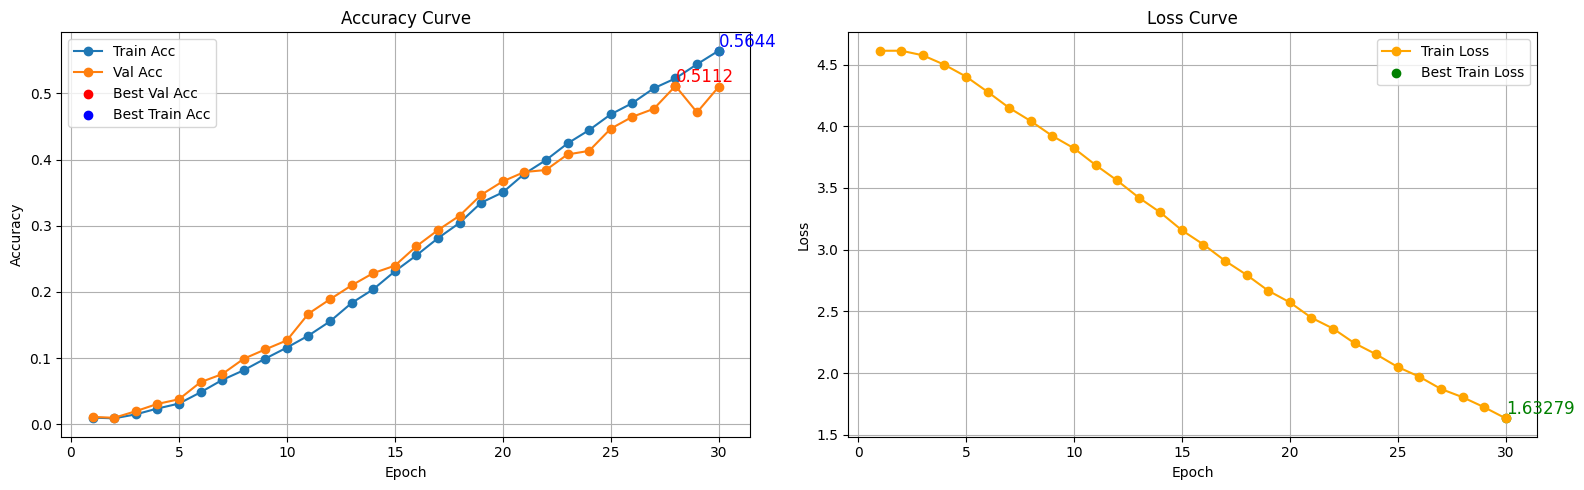

In [10]:
plot_acc_loss(train_acc, loss, val_acc)

In [11]:
# 密集评估 (Dense Testing): 将 VGG 的 3 个全连接层映射为卷积层
class DenseVGGNet(nn.Module):
    def __init__(self, trained_vgg):
        super().__init__()
        self.features = trained_vgg.features  # 复用已训练特征层

        fc1 = trained_vgg.classifier[0]  # Linear(512*4*4 -> 4096)
        fc2 = trained_vgg.classifier[3]  # Linear(4096 -> 4096)
        fc3 = trained_vgg.classifier[6]  # Linear(4096 -> num_classes)

        self.classifier_conv = nn.Sequential(
            nn.Conv2d(512, 4096, kernel_size=4, stride=1, padding=0),  # 对应 fc1 (4x4)
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(4096, 4096, kernel_size=1, stride=1, padding=0),  # 对应 fc2
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(
                4096, fc3.out_features, kernel_size=1, stride=1, padding=0
            ),  # 对应 fc3
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))  # 全局池化到 num_classes x 1 x 1
        self.load_fc_weights(fc1, fc2, fc3)

    def load_fc_weights(self, fc1, fc2, fc3):
        with torch.no_grad():
            self.classifier_conv[0].weight.copy_(
                fc1.weight.view(4096, 512, 4, 4)
            )  # type: ignore # 对应 fc1
            self.classifier_conv[0].bias.copy_(fc1.bias)  # type: ignore

            self.classifier_conv[3].weight.copy_(fc2.weight.view(4096, 4096, 1, 1))  # type: ignore
            self.classifier_conv[3].bias.copy_(fc2.bias)  # type: ignore

            self.classifier_conv[6].weight.copy_(
                fc3.weight.view(fc3.out_features, 4096, 1, 1)
            )  # type: ignore
            self.classifier_conv[6].bias.copy_(fc3.bias)  # type: ignore

    def forward(self, x):
        x = self.features(x)
        x = self.classifier_conv(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)  # [B, num_classes]
        return x

# 从已训练 model 构建 dense model（兼容 DataParallel）
base_model = model.module if hasattr(model, "module") else model
dense_model = DenseVGGNet(base_model).to(device)
if hasattr(model, "module"):
    dense_model = nn.DataParallel(dense_model)

print("Dense model ready.")

Dense model ready.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.models import vgg19
from PIL import Image
from tqdm import tqdm

class VGG19DenseEvaluator:
    def __init__(self, model, scales=[384, 512, 640], num_classes=1000, device='cuda'):
        self.model = model.to(device)
        self.model.eval()
        self.scales = scales
        self.num_classes = num_classes
        self.device = device
    
    def preprocess_batch(self, imgs_pil, scale):
        # imgs_pil: list of PIL.Image
        imgs = [T.Resize((scale, scale))(img) for img in imgs_pil]
        imgs = [T.ToTensor()(img) for img in imgs]
        imgs = torch.stack(imgs, dim=0).to(self.device)
        return imgs
    
    @torch.no_grad()
    def predict_single_scale_batch(self, imgs_pil, scale, flip=True):
        # imgs_pil: list of PIL.Image
        imgs = self.preprocess_batch(imgs_pil, scale)  # [B, 3, S, S]
        out = self.model(imgs)  # [B, num_classes, h, w] or [B, num_classes]
        if out.dim() == 4:
            out = out.mean(dim=[2, 3])
        elif out.dim() == 2:
            pass
        else:
            raise ValueError(f"Unexpected out shape: {out.shape}")
        if flip:
            imgs_flip = torch.flip(imgs, dims=[3])
            out_flip = self.model(imgs_flip)
            if out_flip.dim() == 4:
                out_flip = out_flip.mean(dim=[2, 3])
            elif out_flip.dim() == 2:
                pass
            else:
                raise ValueError(f"Unexpected out_flip shape: {out_flip.shape}")
            out = (out + out_flip) / 2.0
        return out  # [B, num_classes]
    
    @torch.no_grad()
    def predict_multiscale_batch(self, imgs_pil, flip=True):
        # imgs_pil: list of PIL.Image
        outputs = []
        for scale in self.scales:
            out = self.predict_single_scale_batch(imgs_pil, scale, flip=flip)
            outputs.append(out)
        final_out = torch.stack(outputs).mean(dim=0)
        return final_out  # [B, num_classes]
    
    @torch.no_grad()
    def evaluate(self, test_loader):
        """批量密集评估，极大加速推理"""
        correct, total = 0, 0
        to_pil = T.ToPILImage()
        for batch in tqdm(test_loader, desc="批量密集评估中"):
            # 处理 batch 格式
            if isinstance(batch[0], list):
                images, labels = batch
            else:
                images = [to_pil(img) for img in batch[0]] if isinstance(batch[0], torch.Tensor) else batch[0]
                labels = batch[1]
            # 保证 images 为 PIL list
            images = [to_pil(img) if isinstance(img, torch.Tensor) else img for img in images]
            logits = self.predict_multiscale_batch(images, flip=True)  # [B, num_classes]
            preds = logits.argmax(dim=1).cpu()
            labels = torch.tensor(labels).cpu() if not torch.is_tensor(labels) else labels.cpu()
            correct += (preds == labels).sum().item()
            total += len(labels)
        accuracy = correct / max(total, 1)
        print(f"批量密集评估正确率: {accuracy:.4f} ({correct}/{total})")
        return accuracy

In [13]:
def test_dense_evaluation(model, test_loader, device):
    # 从已训练 model 构建 dense model（兼容 DataParallel）
    base_model = model.module if hasattr(model, "module") else model
    dense_model = DenseVGGNet(base_model).to(device)
    if hasattr(model, "module"):
        dense_model = nn.DataParallel(dense_model)
    print("Dense model ready.")
    
    evaluator = VGG19DenseEvaluator(
        dense_model, scales=[150, 275, 200], num_classes=NUM_CLASSES, device=device
    )
    evaluator.evaluate(test_loader)


def test(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="测试中"):
            if isinstance(images, list):
                images = torch.stack(
                    [
                        img if torch.is_tensor(img) else T.ToTensor()(img)
                        for img in images
                    ]
                )
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    print(f"测试准确率: {accuracy:.4f}")

In [14]:
test_base_transform = T.Compose(
    [
        T.Resize((128, 128)),
        T.ToTensor(),
        T.Normalize(mean=mean, std=std),
    ]
)


def test_collate_fn(batch):
    images, labels = zip(*batch)
    # 自动将所有 images 转为 tensor 并 stack
    images = [T.ToTensor()(img) if not torch.is_tensor(img) else img for img in images]
    return torch.stack(images), torch.tensor(labels, dtype=torch.long)


test_dataset = DataSetLoader_test(
    root_dir=test_dir,
    num_classes=NUM_CLASSES,
    transform=test_base_transform,
    return_pil=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=True,
    collate_fn=test_collate_fn,
)

In [15]:
test_dense_evaluation(model, test_loader, device)
test(model, test_loader, device)

Dense model ready.


批量密集评估中: 100%|██████████| 395/395 [05:37<00:00,  1.17it/s]


批量密集评估正确率: 0.0142 (359/25250)


测试中: 100%|██████████| 395/395 [00:33<00:00, 11.73it/s]

测试准确率: 0.4247


In [16]:
train_acc1, loss1, val_acc1 = train(
    model,
    epoch=50,
    train_loader=train_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    scheduler=scheduler_base,
    val_loader=val_loader,
 )

验证中: 100%|██████████| 237/237 [00:19<00:00, 11.88it/s]


Epoch [1/50] 平均损失: 1.5597 训练准确率: 0.5808 验证准确率: 0.5393


验证中: 100%|██████████| 237/237 [00:19<00:00, 11.86it/s]


Epoch [2/50] 平均损失: 1.4882 训练准确率: 0.5979 验证准确率: 0.5310


验证中: 100%|██████████| 237/237 [00:20<00:00, 11.83it/s]


...

Epoch [48/50] 平均损失: 0.0235 训练准确率: 0.9929 验证准确率: 0.7748


验证中: 100%|██████████| 237/237 [00:33<00:00,  7.02it/s]


Epoch [49/50] 平均损失: 0.0230 训练准确率: 0.9929 验证准确率: 0.7753


验证中: 100%|██████████| 237/237 [00:33<00:00,  7.04it/s]

Epoch [50/50] 平均损失: 0.0216 训练准确率: 0.9933 验证准确率: 0.7754


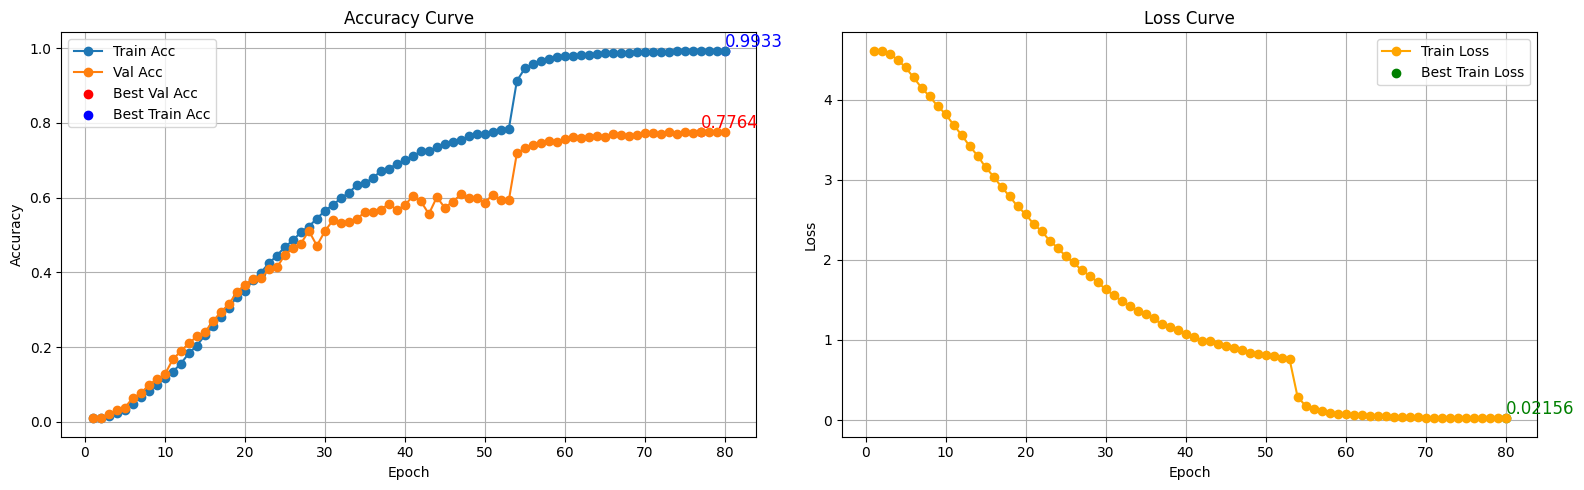

In [17]:
plot_acc_loss(train_acc + train_acc1, loss + loss1, val_acc + val_acc1)

In [18]:
save_checkpoint("vggnet19_food101_80_mean.pth", model, optimizer, scheduler_base, epoch=100, best_acc=max(val_acc + val_acc1))

Saved checkpoint to vggnet19_food101_80_mean.pth


In [19]:
test_dense_evaluation(model, test_loader, device)
test(model, test_loader, device)

Dense model ready.


批量密集评估中: 100%|██████████| 395/395 [08:59<00:00,  1.37s/it]


批量密集评估正确率: 0.0148 (373/25250)


测试中: 100%|██████████| 395/395 [00:51<00:00,  7.65it/s]

测试准确率: 0.4847


In [23]:
test(model, val_loader, device)

测试中: 100%|██████████| 237/237 [00:33<00:00,  7.06it/s]

测试准确率: 0.7754


In [21]:
# def load_checkpoint(path, model, optimizer=None, scheduler=None, map_location=device):
#   checkpoint = torch.load(path, map_location=map_location)
# #   如果当前 model 是 DataParallel，需要把 state_dict 加载到 module
#   target = model.module if hasattr(model, "module") else model
#   target.load_state_dict(checkpoint["model_state_dict"])
#   if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
#     optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
#   if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
#     scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
#   print(f"Loaded checkpoint from {path}, epoch={checkpoint.get('epoch')}, best_acc={checkpoint.get('best_acc')}")
#   return checkpoint

In [22]:
# model = VGGNet(num_classes=101)
# load_checkpoint("vggnet19_food101_80.pth", model, optimizer=None, scheduler=None)

# if torch.cuda.device_count() > 1:
#     print("使用多卡训练, GPU 数量:", torch.cuda.device_count())
#     model = nn.DataParallel(model)
# model = model.to(device)